In [7]:
import numpy as np
from itertools import product
import pandas as pd
from pathlib import Path
import sqlite3
import json
from datetime import datetime as dt
import matplotlib.pyplot as plt
import time

In [4]:
import importlib
import datagen
import make_fig
import processing

importlib.reload(processing)

from datagen import (
    make_decks,
    get_next_seed,
    save_decks,
    get_total_decks
)

In [2]:
import sys
!{sys.executable} -m ensurepip --upgrade
!{sys.executable} -m pip install seaborn

Looking in links: /var/folders/3g/djm6xh950cq0tvy9mbzx207r0000gn/T/tmpky6g73tt
Processing /private/var/folders/3g/djm6xh950cq0tvy9mbzx207r0000gn/T/tmpky6g73tt/pip-23.2.1-py3-none-any.whl
  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 3.1 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


In [5]:
from datagen import make_decks, get_next_seed, save_decks, generate_decks, get_total_decks
from processing import iterate_all_combos, iterate_all_combos_for_points
from make_fig import (load_data, process_data, create_heatmap_data, plot_heatmap
)

Created 25000 new decks.
Total decks available: 200000

Processing Tricks strategy...
Saved 56 rows to 'tricks.db' in table 'trick_stats'.

Processing Cards strategy...
Successfully saved 56 rows to 'points.db' in table 'combo_stats'.

25,000 new decks successfully added.
Results now include 200,000 total decks.



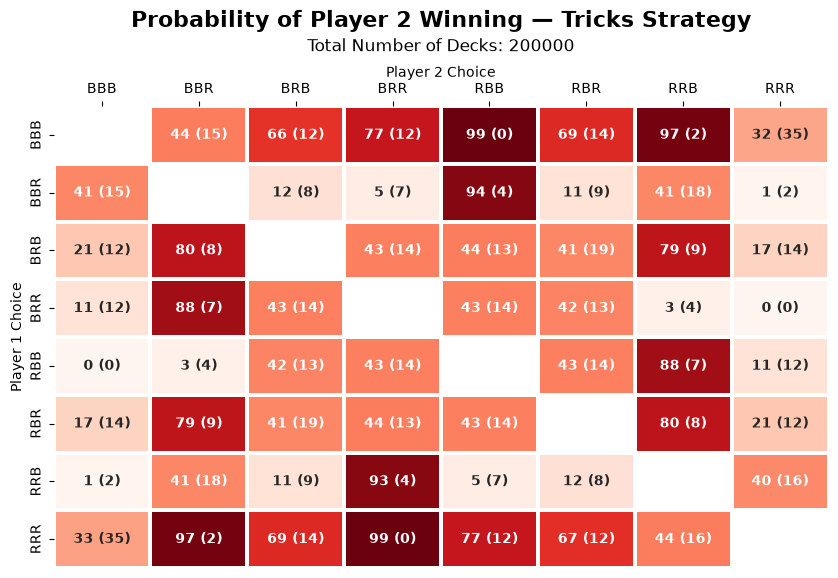

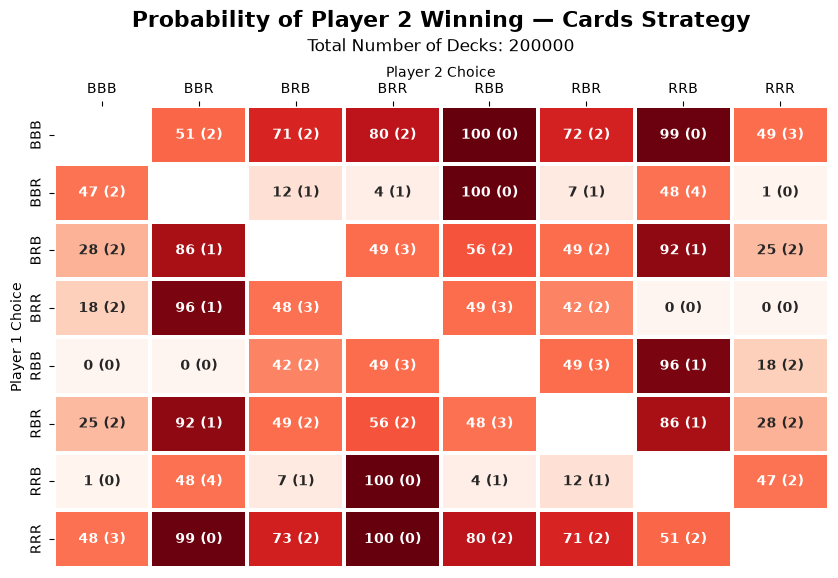


Total run time: 1 minutes, 43.51 seconds


In [10]:
def main(n_decks):

    # 1. Generate new decks

    seed = get_next_seed()

    new_deck_files = generate_decks(n_decks=n_decks, batch_size=1000)

    total_decks = get_total_decks()

    print(f"Created {n_decks} new decks.")

    # 2. Count ALL saved decks

    total_decks = get_total_decks()

    print(f"Total decks available: {total_decks}")

    # 3. Run Tricks strategy

    print("\nProcessing Tricks strategy...")

    iterate_all_combos(deck_files=new_deck_files)

    tricks_data = load_data(
        "tricks.db",
        "trick_stats"
    )

    tricks_data = process_data(tricks_data)

    tricks_heatmap, tricks_labels = create_heatmap_data(
        tricks_data
    )

    # 4. Run Cards strategy

    print("\nProcessing Cards strategy...")

    iterate_all_combos_for_points(deck_files=new_deck_files)

    cards_data = load_data(
        "points.db",
        "combo_stats"
    )

    cards_data = process_data(cards_data)

    cards_heatmap, cards_labels = create_heatmap_data(
        cards_data
    )

    print(f"\n{n_decks:,} new decks successfully added.")
    print(f"Results now include {total_decks:,} total decks.\n")

    # 5. Display BOTH graphs

    plot_heatmap(
        tricks_heatmap,
        tricks_labels,
        n_decks=total_decks,
        strategy="tricks"
    )

    plot_heatmap(
        cards_heatmap,
        cards_labels,
        n_decks=total_decks,
        strategy="cards"
    )


if __name__ == "__main__":

    n_decks = int(
        input("How many additional decks would you like to simulate? ")
    )

    start_time = time.perf_counter()

    main(
        n_decks=n_decks
    )

    end_time = time.perf_counter()

    elapsed_time = end_time - start_time

    minutes = int(elapsed_time // 60)
    seconds = elapsed_time % 60

    print(f"\nTotal run time: "f"{minutes} minutes, {seconds:.2f} seconds")